<h2>Stock Market Analysis for Magnificent 7<h2>

In this project, we will discover: 
1. What was the change of stock prices from 2014 to 2024?
2. What was the moving average for different stocks? (5, 50, 120 days)
3. What are the anticipated returns and risks associated with each stock per share?  
4. Predict the stock price using LSTM method.

In [57]:
# !%pip install --upgrade yfinance
# %pip install matplotlib
# %pip install torch
# %pip install scikit-learn
# %pip install tensorflow
# %pip install pandas-datareader
# %pip install yahoofinancials
# %pip install keras

In [58]:
# Import the library we need
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_score
from sklearn.preprocessing import MinMaxScaler
from pandas_datareader import DataReader
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
from time import time

<h2>1. What was the change of stock prices from 2014 to 2026?<h2>

We want to implement the data from Yahoo Finance. We decide to take 10 years from 1/1/2014 to 1/1/2026. 

In [59]:
import pandas as pd
import yfinance as yf

# Fixed ticker symbol: AAPL instead of APPL
tech_list = ['AAPL', 'AMZN', 'NVDA', 'META', 'MSFT', 'GOOGL', 'TSLA']

def get_historical_data(tickers, start_date, end_date):
    data = pd.DataFrame()
    for ticker in tickers:
        try:
            # Use yf.Ticker() when calling .history()
            df = yf.Ticker(ticker).history(start=start_date, end=end_date)
            df = df[['Close']].rename(columns={'Close': ticker})
            df.index = df.index.date  # Strip time/timezone component from index

            data = pd.concat([data, df], axis=1)
        except Exception as e:
            print(f"{ticker} failed: {e}")

    data.index.name = 'Date'
    return data

start_date = "2014-01-01"
end_date = "2025-12-31"

ticker_dfs = get_historical_data(tech_list, start_date, end_date)
print(ticker_dfs.head())

                 AAPL       AMZN      NVDA       META       MSFT      GOOGL  \
Date                                                                          
2014-01-02  17.110128  19.898500  0.372991  54.190971  30.636784  27.593287   
2014-01-03  16.734287  19.822001  0.368523  54.042404  30.430655  27.392002   
2014-01-06  16.825546  19.681499  0.373462  56.657352  29.787579  27.697401   
2014-01-07  16.705219  19.901501  0.379576  57.370518  30.018431  28.231358   
2014-01-08  16.811001  20.096001  0.384750  57.677582  29.482517  28.290108   

                 TSLA  
Date                   
2014-01-02  10.006667  
2014-01-03   9.970667  
2014-01-06   9.800000  
2014-01-07   9.957333  
2014-01-08  10.085333  


Now we can put all the stock price together to see how the price changed during 2014 to 2024.

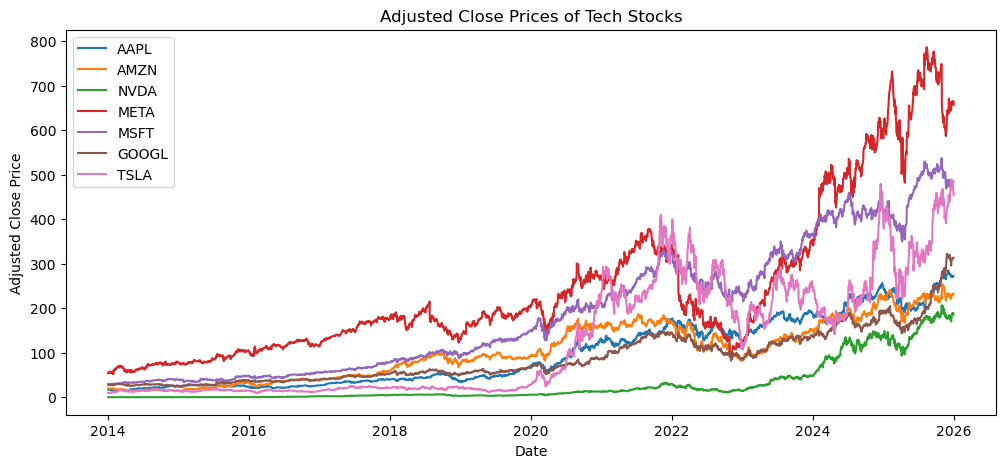

In [60]:
plt.figure(figsize=(12, 5)) 
for ticker in tech_list:
    # Plot the adjusted close price for the current ticker
    ticker_df = ticker_dfs[ticker]
    plt.plot(ticker_df.index, ticker_df, label = ticker)

plt.title('Adjusted Close Prices of Tech Stocks')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()

<h2>2. What was the moving average of the stocks?<h2>

Moving average is a popular statistical technique used to analyze time-series data by calculating the average of certain period data points, we can found many different types of moving average such as Simple Moving Average(SMA), Exponential Moving Average(EMA), etc. It is widely used in financial analysis to identify the trends and potential opportunities in investment. For the following, I am going to use 5 days, 50 days, and 120 days as example.

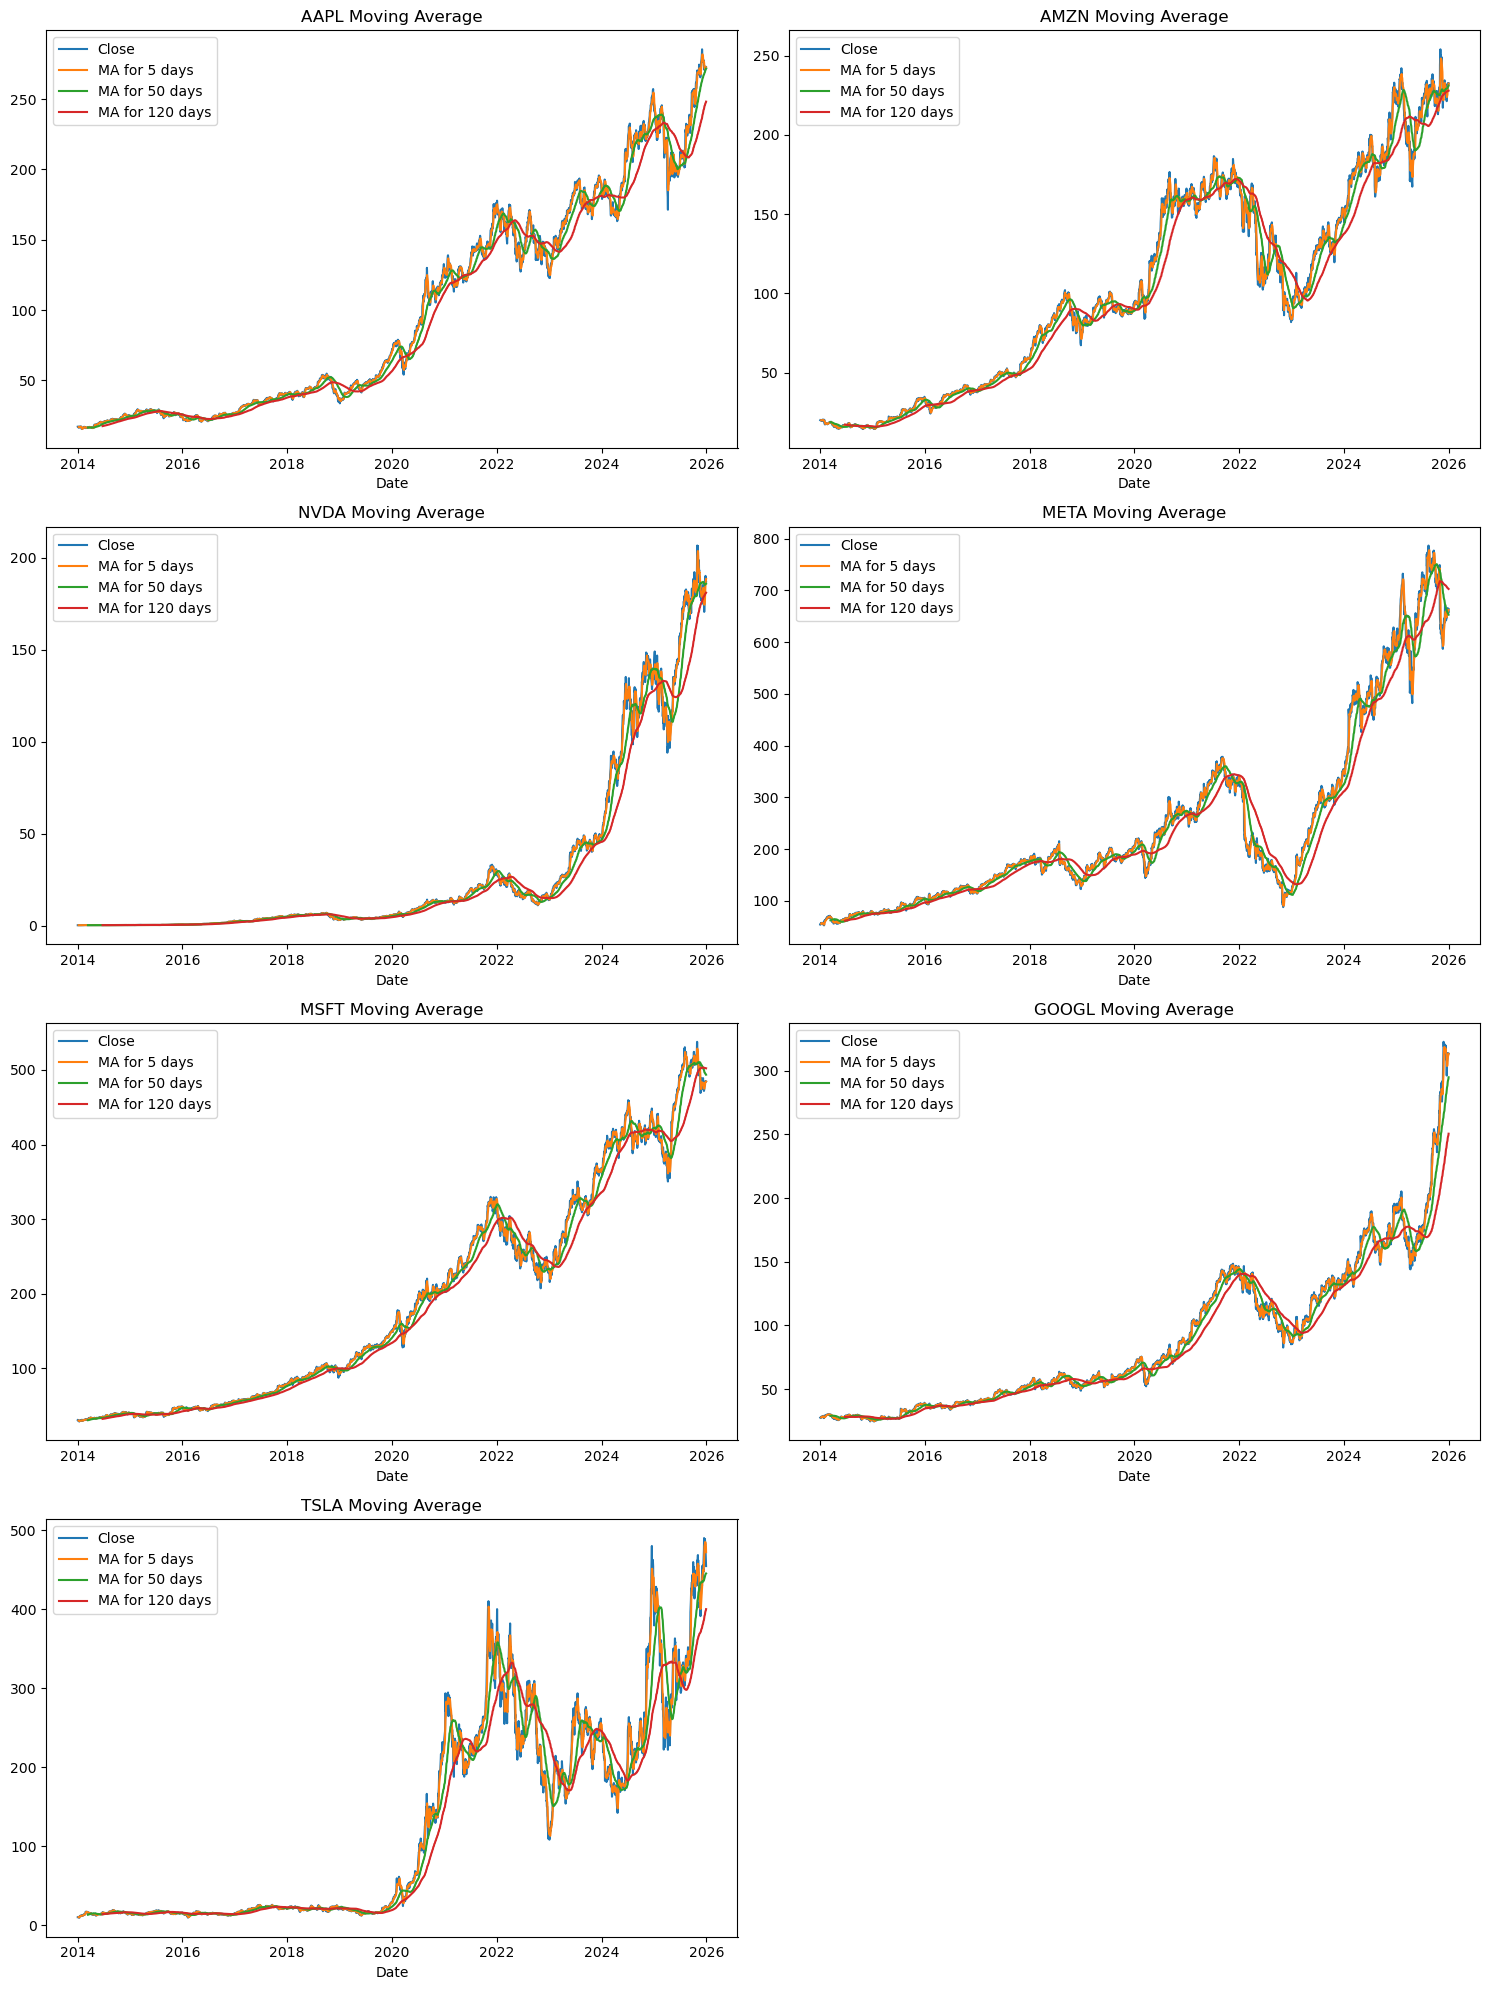

In [ ]:
def add_moving_averages(series_or_df, ticker_name, ma_days):
    df = pd.DataFrame({"Close": series_or_df})
    for ma in ma_days:
        column_name = f"MA for {ma} days"
        df[column_name] = df["Close"].rolling(window=ma, center=False).mean()
    return df


ma_days = [5, 50, 120]

AAPL_df = add_moving_averages(ticker_dfs["AAPL"], "AAPL", ma_days)
AMZN_df = add_moving_averages(ticker_dfs["AMZN"], "AMZN", ma_days)
NVDA_df = add_moving_averages(ticker_dfs["NVDA"], "NVDA", ma_days)
META_df = add_moving_averages(ticker_dfs["META"], "META", ma_days)
MSFT_df = add_moving_averages(ticker_dfs["MSFT"], "MSFT", ma_days)
GOOGL_df = add_moving_averages(ticker_dfs["GOOGL"], "GOOGL", ma_days)
TSLA_df = add_moving_averages(ticker_dfs["TSLA"], "TSLA", ma_days)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))

plot_cols = ["Close", "MA for 5 days", "MA for 50 days", "MA for 120 days"]

AAPL_df[plot_cols].plot(ax=axes[0, 0], title="AAPL Moving Average")
AMZN_df[plot_cols].plot(ax=axes[0, 1], title="AMZN Moving Average")
NVDA_df[plot_cols].plot(ax=axes[1, 0], title="NVDA Moving Average")
META_df[plot_cols].plot(ax=axes[1, 1], title="META Moving Average")
MSFT_df[plot_cols].plot(ax=axes[2, 0], title="MSFT Moving Average")
GOOGL_df[plot_cols].plot(ax=axes[2, 1], title="GOOGL Moving Average")
TSLA_df[plot_cols].plot(ax=axes[3, 0], title="TSLA Moving Average")

axes[3, 1].axis("off")

plt.tight_layout()
plt.show()


We can notice that the greater the number of moving average days, the smoother the trend line will becomes.

<h2>3. Visualzing Risk-Return Profiles for companies. <h2>

Now we know the moving average of these companies, but what is more important is which companies we want to put our bet on. Since all the companies we listed are rank A company, we need to see the sharpe ratio to determine which company can bring us the highest expected return with the lowest risk? And how much value do we put at risk by investing those company? 

In [62]:
adjclose_df = pd.DataFrame()

# Take only the adj close price 
for ticker in tech_list:
    adjclose_df[ticker] = ticker_dfs[ticker]

# Simplified Risk free rate
# We average the 2014 and 2024 risk-free rate  
Risk_free_rate = (1.0 + ((0.03 + 0.0395) / 2.0)) ** (1.0 / 252.0) - 1

# Calculate the daily percentage return
rets = adjclose_df.pct_change()
rets = rets.dropna()
rets

,AAPL,AMZN,NVDA,META,MSFT,GOOGL,TSLA
Date,,,,,,,
2014-01-03,-0.021966,-0.003845,-0.011980,-0.002742,-0.006728,-0.007295,-0.003598
2014-01-06,0.005453,-0.007088,0.013402,0.048387,-0.021133,0.011149,-0.017117
2014-01-07,-0.007151,0.011178,0.016373,0.012587,0.007750,0.019278,0.016054
2014-01-08,0.006332,0.009773,0.013631,0.005352,-0.017853,0.002081,0.012855
2014-01-09,-0.012770,-0.002264,-0.037286,-0.017345,-0.006432,-0.009630,-0.024788
...,...,...,...,...,...,...,...
2025-12-23,0.005130,0.016241,0.030051,0.005200,0.003980,0.014752,-0.006486
2025-12-24,0.005324,0.001034,-0.003171,0.003925,0.002403,-0.000827,-0.000330
2025-12-26,-0.001498,0.000602,0.010180,-0.006381,-0.000635,-0.001847,-0.021034


AAPL     0.052770
AMZN     0.043148
NVDA     0.079584
META     0.041410
MSFT     0.055332
GOOGL    0.046492
TSLA     0.049334
dtype: float64


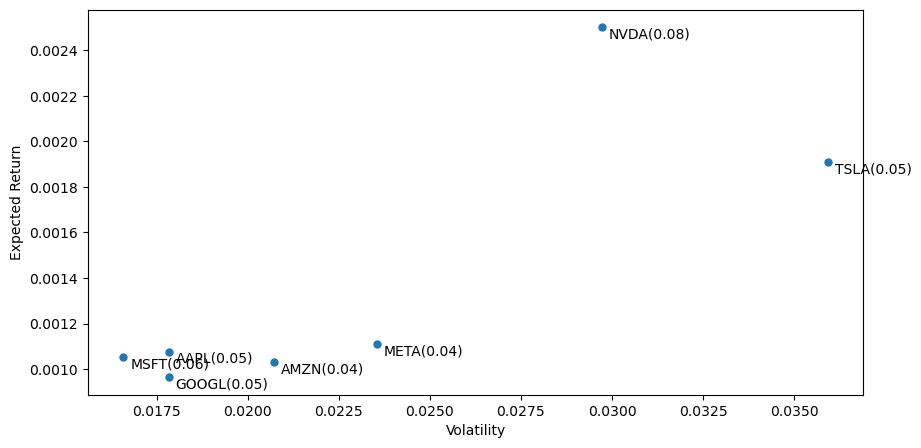

In [63]:
plt.figure(figsize=(10, 5))

# Calculate expected return over risk
sharpe_ratio = (rets.mean() - Risk_free_rate) / rets.std()
print(sharpe_ratio)

# Swap rets.std() and rets.mean() to plot volatility on x-axis and return on y-axis
plt.scatter(rets.std(), rets.mean(), s=25)

plt.ylabel('Expected Return')
plt.xlabel('Volatility')

for label, x, y, ratio in zip(rets.columns, rets.std(), rets.mean(), sharpe_ratio):
    plt.annotate(
        f'{label}({ratio:.2f})',  # Include the ratio in the annotation text
        xy=(x, y),
        xytext=(5, -5),  # Adjust the position of the text relative to the point
        textcoords='offset points',
        ha='left',  # Align text to the left of the point
        va='center')  # Align text vertically centered with the point

plt.show()


For individuals who are pursuing stability and safety, investing in stocks with lower risk and moderate expected returns would be advisable. In this case, consider stocks like AAPL and MSFT as it has the lowest risk among all listed. For those willing to take on more risk for potentially higher returns, NVDA could be their best choices as these stocks have the highest expected return with the higher level of risk.

<h2>4. Predict the closing price stock price using LSTM.</h2>

Take AAPL as example to predict the future stock price. 

In [64]:
# Ensure the data is not leaking future information
df = ticker_dfs['AAPL']
df
# adjclose = adjclose.fillna(method='ffill')
dataset = df.values

# print(dataset)
# Take the 95% of the data to be the training set
training_data_len = int(np.ceil(len(dataset) * 0.95))
print(training_data_len)


2867


In [65]:
# Scale the data
scaler = MinMaxScaler(feature_range = (0, 1))
scaled_data = scaler.fit_transform(dataset.reshape(-1, 1))
scaled_data


array([[0.00611326],
       [0.00472101],
       [0.00505907],
       ...,
       [0.95274994],
       [0.95408005],
       [0.9515678 ]], shape=(3017, 1))

In [66]:
# Create the training data set 
train_data = scaled_data[0:training_data_len, :]

# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):        # we are doing 60 days
    x_train.append(train_data[i-60:i, 0])   # put day 1 to 59 in x_train
    y_train.append(train_data[i, 0])        # put day 60 in y_train
    if i<= 61:
        print(x_train)
        print(y_train)
        print()
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data for LSTM structure [sample, timesteps, features(close price)]
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

[array([6.11325538e-03, 4.72101025e-03, 5.05906505e-03, 4.61333239e-03,
       5.00518373e-03, 4.20996432e-03, 3.79974274e-03, 4.11944850e-03,
       5.34094931e-03, 6.59796122e-03, 6.24157857e-03, 4.68549917e-03,
       5.64803613e-03, 5.92765944e-03, 6.46274919e-03, 5.30429362e-03,
       5.81191986e-03, 7.70041582e-04, 1.11189408e-04, 0.00000000e+00,
       9.39567098e-05, 2.00542959e-04, 1.03243926e-03, 1.46787046e-03,
       1.81021754e-03, 2.63674407e-03, 3.70994760e-03, 4.51340535e-03,
       4.50878453e-03, 5.48977652e-03, 5.43905346e-03, 5.66960703e-03,
       4.67593958e-03, 3.95894206e-03, 3.27882634e-03, 3.54395129e-03,
       2.91106827e-03, 2.36818530e-03, 3.55777842e-03, 3.39296205e-03,
       3.56815054e-03, 3.96930005e-03, 4.09840751e-03, 3.91281156e-03,
       3.87710971e-03, 3.93241120e-03, 4.52839123e-03, 4.58833473e-03,
       3.90128777e-03, 3.21426201e-03, 3.45060221e-03, 3.98775508e-03,
       3.97161753e-03, 3.67654202e-03, 4.15719227e-03, 4.88573478e-03,
     

In [67]:
# Build the LSTM model
model = Sequential([
    Input(shape=(x_train.shape[1], 1)),
    LSTM(128, return_sequences=True),       # LSTM  layer (128) units 
    LSTM(64, return_sequences=False),       # LSTM  layer  (64) units 
    Dense(25),                              # Dense layer  (25) units
    Dense(1)                                # output
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(x_train, y_train, batch_size=16, epochs=50)
print(history)


Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0020
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.3912e-04
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 3.4119e-04
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.5809e-04
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3.0440e-04
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.5343e-04
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.9169e-04
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.8524e-04
Epoch 9/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.1796e-04
Epoch 10/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.5244e-04
Epoch 11/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.6245e-04
Epoch 12/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.3103e-04
Epoch 13/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.3421e-04
Epoch 14/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.

In [68]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002 
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001F506740A40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


np.float64(39.458445101543624)

In [69]:
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

None


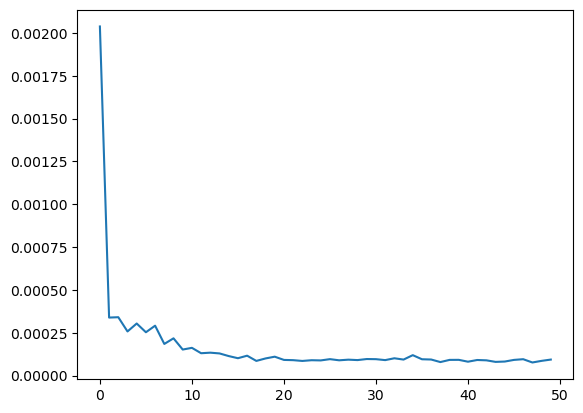

In [70]:
plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])

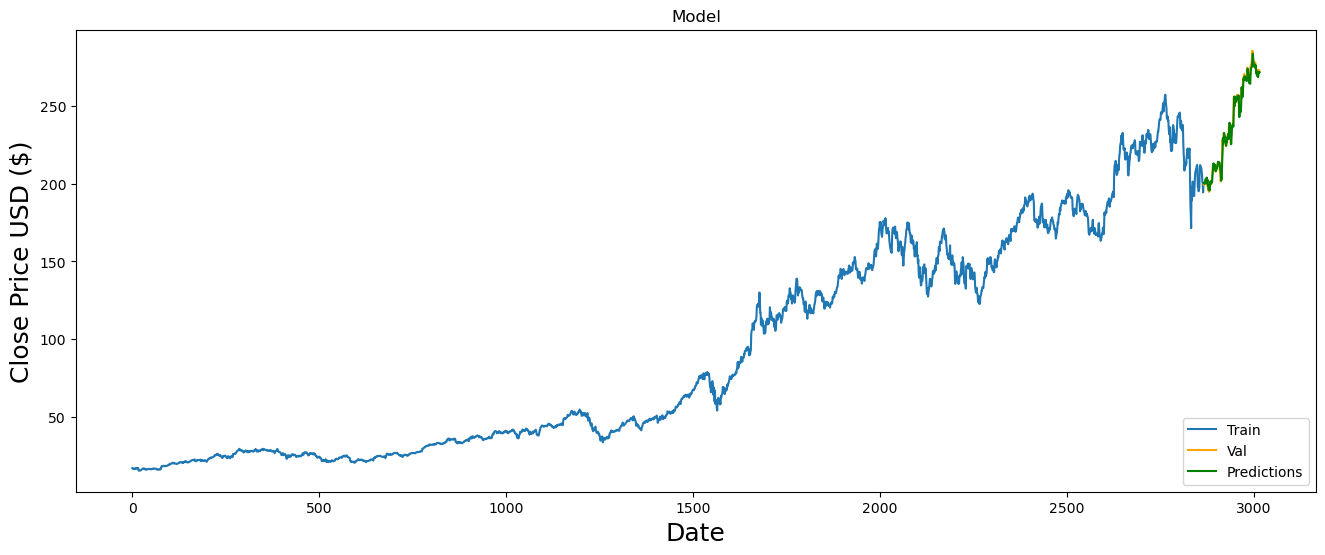

In [71]:
# Convert 'valid' and 'predictions' into a DataFrame with proper alignment
valid = pd.DataFrame({
    'adjclose': dataset[training_data_len:],  # Original unscaled values
    'Predictions': predictions.flatten()      # Flatten predictions
})

# Define the x-axis for plotting: index from 'training_data_len' onwards
valid.index = range(training_data_len, len(dataset))

# Visualize the data
plt.figure(figsize=(16, 6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# Plot the training data
plt.plot(range(0, training_data_len), dataset[:training_data_len], label='Train')

# Plot the validation (actual) and predictions data
plt.plot(valid.index, valid['adjclose'], label='Val', color='orange')
plt.plot(valid.index, valid['Predictions'], label='Predictions', color='green')

plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
def directional_accuracy(y_true, y_pred, y_prev):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    y_prev = np.asarray(y_prev).ravel()

    actual_direction = np.sign(y_true - y_prev)

    pred_direction = np.sign(y_pred - y_prev)

    correct_directions = actual_direction == pred_direction

    accuracy = np.mean(correct_directions)
    return float(accuracy)

In [ ]:
y_prev = dataset[training_data_len - 1 : -1]

da = directional_accuracy(y_true=y_test, y_pred=predictions, y_prev=y_prev)

print(f"LSTM Accuracy: {da * 100:.2f}%")

LSTM Accuracy: 54.00%
